# Movie Rating Prediction with Python

This Machine Learning project predicts IMDb movie ratings using the **IMDb India Movies** dataset.

Dataset link: https://www.kaggle.com/datasets/adrianmcmahon/imdb-india-movies

## Project Goal

The goal of this project is to predict movie ratings based on features such as:
- Genre
- Director
- Actors
- Duration
- Year
- Votes


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset

Download the dataset from Kaggle and place the CSV file in the same folder as this notebook.

Expected file name: `IMDb Movies India.csv`

If your file name is different, update the file name in the code below.


In [3]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 3. Dataset Information

In [4]:
df.shape


(15509, 10)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe(include='all')


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


## 4. Check Missing Values

In [7]:
df.isnull().sum()


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

## 5. Data Cleaning

In [8]:
# Remove rows where rating is missing because Rating is our target column
df = df.dropna(subset=['Rating'])

# Clean Year column
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean Duration column
df['Duration'] = df['Duration'].astype(str).str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Clean Votes column
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [9]:
# Fill missing numerical values
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

# Fill missing categorical values
categorical_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

df.isnull().sum()


Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

## 6. Exploratory Data Analysis

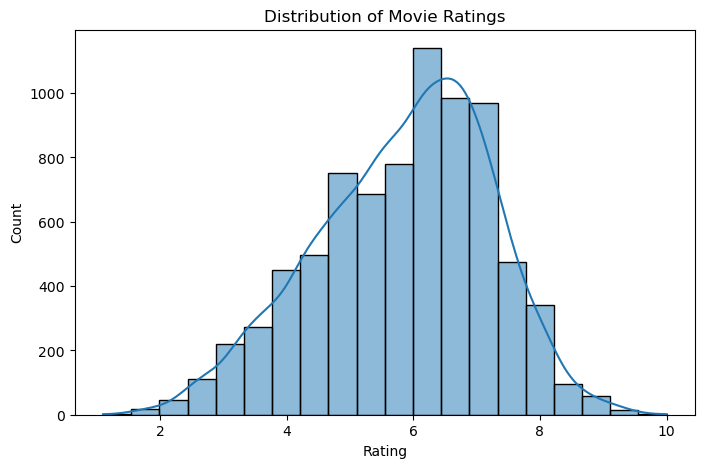

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


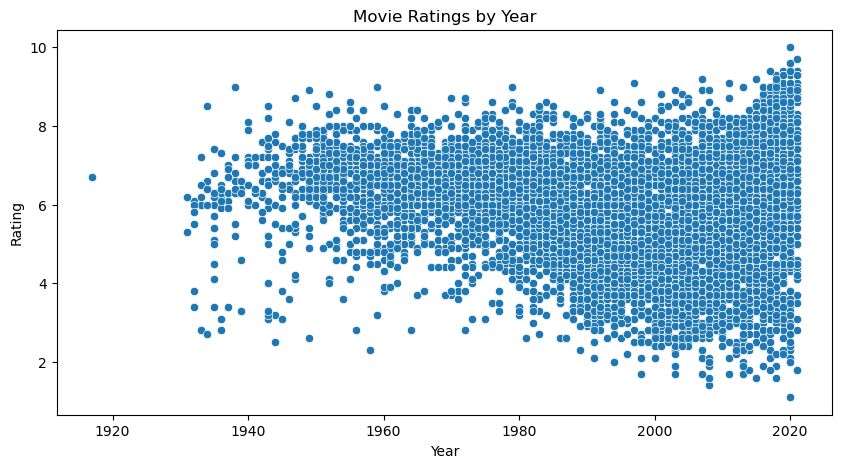

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Year', y='Rating', data=df)
plt.title('Movie Ratings by Year')
plt.xlabel('Year')
plt.ylabel('Rating')
plt.show()


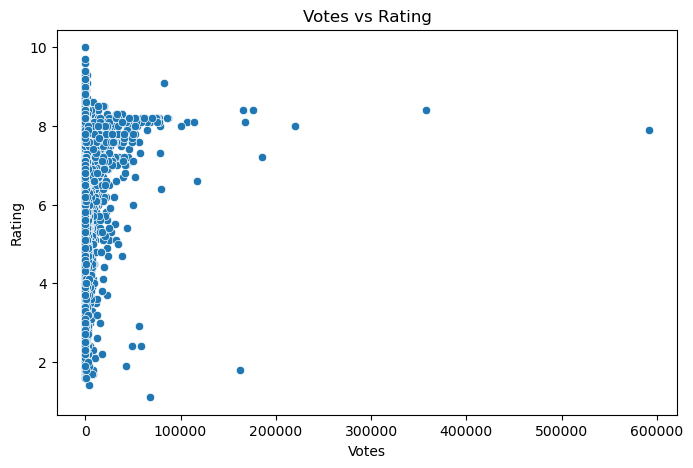

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Votes', y='Rating', data=df)
plt.title('Votes vs Rating')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()


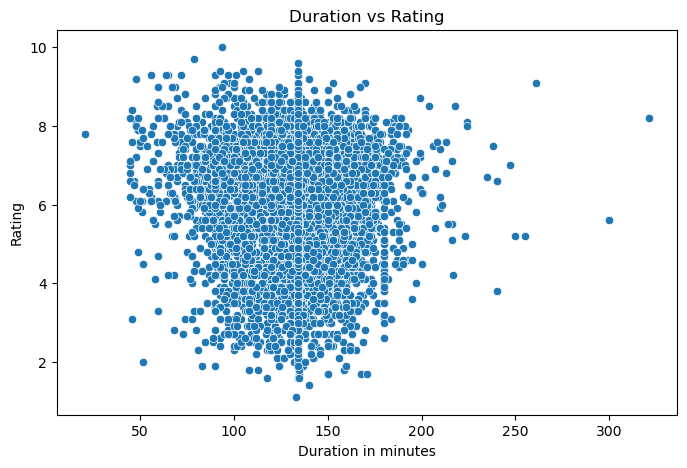

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Duration', y='Rating', data=df)
plt.title('Duration vs Rating')
plt.xlabel('Duration in minutes')
plt.ylabel('Rating')
plt.show()


## 7. Feature Engineering

In [14]:
# Use only the first genre if multiple genres are present
df['Main_Genre'] = df['Genre'].astype(str).str.split(',').str[0]

# Select important features
data = df[['Year', 'Duration', 'Votes', 'Main_Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']]

data.head()


,Year,Duration,Votes,Main_Genre,Director,Actor 1,Actor 2,Actor 3,Rating
1,2019,109.0,8,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0
3,2019,110.0,35,Comedy,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4
5,1997,147.0,827,Comedy,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,4.7
6,2005,142.0,1086,Drama,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,7.4
8,2012,82.0,326,Horror,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.6


## 8. Encode Categorical Columns

In [15]:
label_encoders = {}

for col in ['Main_Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

data.head()


,Year,Duration,Votes,Main_Genre,Director,Actor 1,Actor 2,Actor 3,Rating
1,2019,109.0,8,7,811,1782,2815,377,7.0
3,2019,110.0,35,4,1749,1589,890,2572,4.4
5,1997,147.0,827,4,2005,508,85,2449,4.7
6,2005,142.0,1086,7,2643,931,1388,3030,7.4
8,2012,82.0,326,11,174,2521,1461,1205,5.6


## 9. Split Dataset

In [16]:
X = data.drop('Rating', axis=1)
y = data['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (6335, 8)
Testing data shape: (1584, 8)


## 10. Train Machine Learning Model

In [17]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

## 11. Make Predictions

In [18]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

predictions.head(10)


,Actual Rating,Predicted Rating
0,3.3,4.379
1,5.3,5.038
2,5.7,4.936
3,7.2,5.175
4,3.5,5.292
5,7.2,5.908
6,3.8,5.688
7,6.9,6.948
8,5.2,5.733
9,7.4,6.070


## 12. Model Evaluation

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


Mean Absolute Error: 0.8359406565656565
Mean Squared Error: 1.230962333333333
Root Mean Squared Error: 1.1094874191865958
R2 Score: 0.3378879860300191


## 13. Actual vs Predicted Ratings

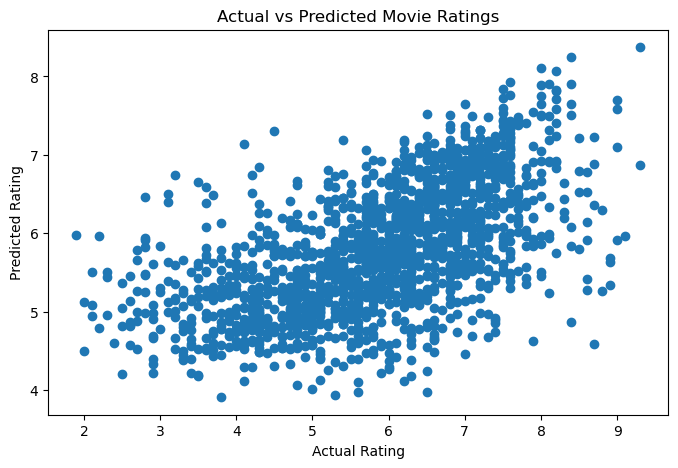

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Movie Ratings')
plt.show()


## 14. Feature Importance

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
2,Votes,0.222230
0,Year,0.202672
7,Actor 3,0.104722
6,Actor 2,0.103537
5,Actor 1,0.102520
1,Duration,0.099151
4,Director,0.091419
3,Main_Genre,0.073748


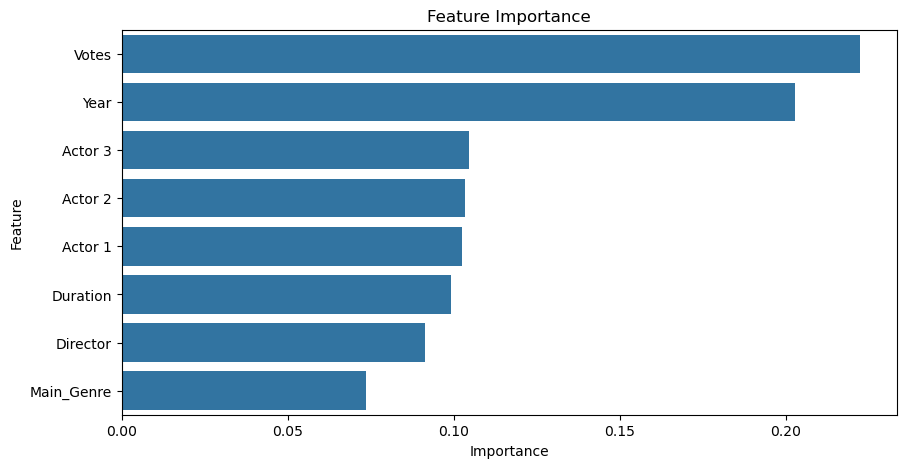

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()


## 15. Conclusion

In this project, we built a Movie Rating Prediction model using Python.

### Steps Completed:
1. Loaded the IMDb India Movies dataset
2. Cleaned missing and messy data
3. Performed exploratory data analysis
4. Converted categorical values into numerical form
5. Trained a Random Forest Regression model
6. Evaluated the model using MAE, RMSE, and R2 Score

This project is useful for learning:
- Data cleaning
- Feature engineering
- Regression modeling
- Model evaluation
